# Manual Network


In [2]:
# Import the necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
import os                                             

In [3]:
# Import the necessary libraries.
import tensorflow as tf
import glob
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Flatten, Convolution2D, Dropout, BatchNormalization

In [4]:
# Ignoring the warings
import warnings
warnings.filterwarnings("ignore")

In [5]:
dir_name_train_MildDemented = 'Dataset/Train/MildDemented'
dir_name_train_ModerateDemented = 'Dataset/Train/ModerateDemented'
dir_name_train_Non_Parkinson = 'Dataset/Train/Non_Parkinson'
dir_name_train_NonDemented= 'Dataset/Train/NonDemented'
dir_name_train_Parkinson = 'Dataset/Train/Parkinson'
dir_name_train_VeryMildDemented = 'Dataset/Train/VeryMildDemented'

In [6]:
def plot_images(item_dir, n=5):
    all_item_dir = os.listdir(item_dir)
    item_files = [os.path.join(item_dir, file) for file in all_item_dir][:n]
    
    plt.figure(figsize=(35, 10))
    for idx, img_path in enumerate(item_files):
        plt.subplot(2, n, idx+1)
        img = plt.imread(img_path)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()

In [7]:
def Images_details_Print_data(data, path):
    print(" ====== Images in: ", path)    
    for k, v in data.items():
        print("%s:\t%s" % (k, v))

def Images_details(path):
    files = [f for f in glob.glob(path + "**/*.*", recursive=True)]
    data = {}
    data['images_count'] = len(files)
    data['min_width'] = 10**100  # No image will be bigger than that
    data['max_width'] = 0
    data['min_height'] = 10**100  # No image will be bigger than that
    data['max_height'] = 0


    for f in files:
        im = Image.open(f)
        width, height = im.size
        data['min_width'] = min(width, data['min_width'])
        data['max_width'] = max(width, data['max_height'])
        data['min_height'] = min(height, data['min_height'])
        data['max_height'] = max(height, data['max_height'])

    Images_details_Print_data(data, path)


Trainned data for  :

 ====== Images in:  Dataset/Train/Parkinson
images_count:	320
min_width:	128
max_width:	176
min_height:	128
max_height:	176



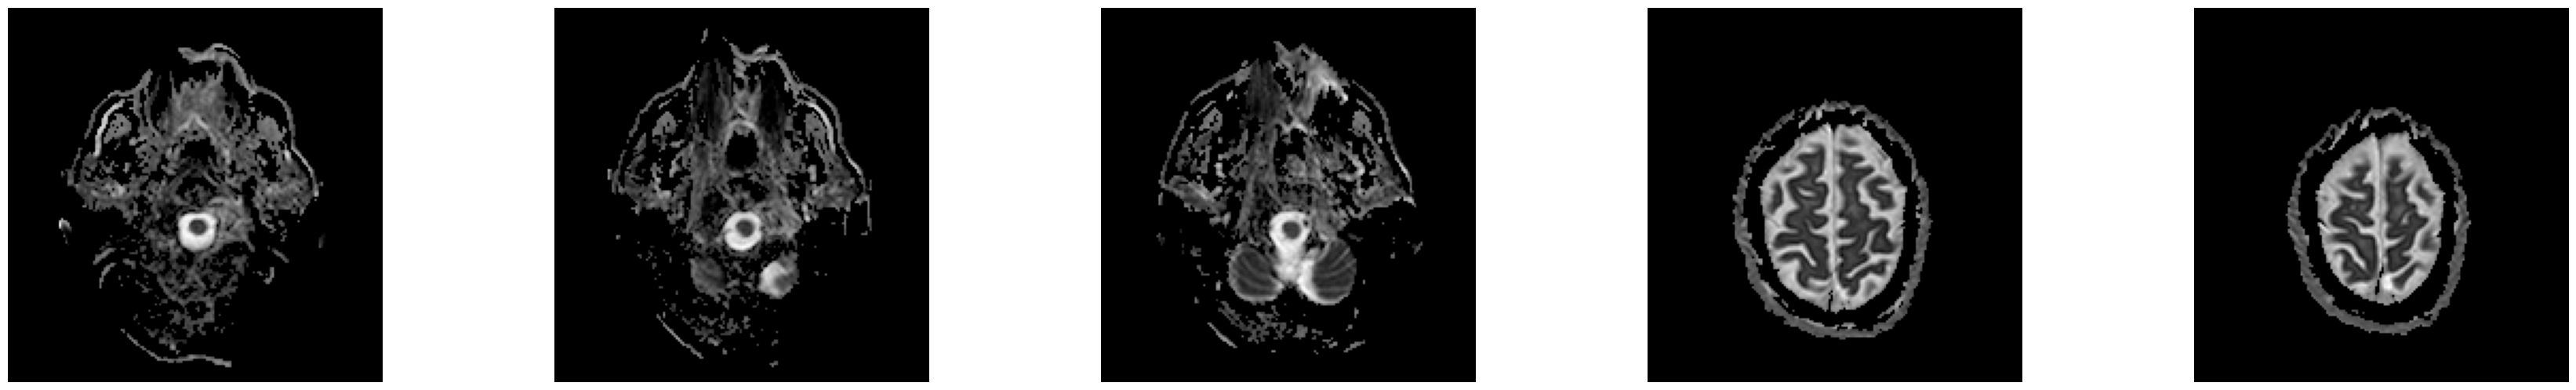

In [8]:
print("")
print("Trainned data for  :")
print("")

Images_details(dir_name_train_Parkinson)
print("")
plot_images(dir_name_train_Parkinson)


Trainned data for  :

 ====== Images in:  Dataset/Train/Non_Parkinson
images_count:	331
min_width:	288
max_width:	336
min_height:	288
max_height:	336



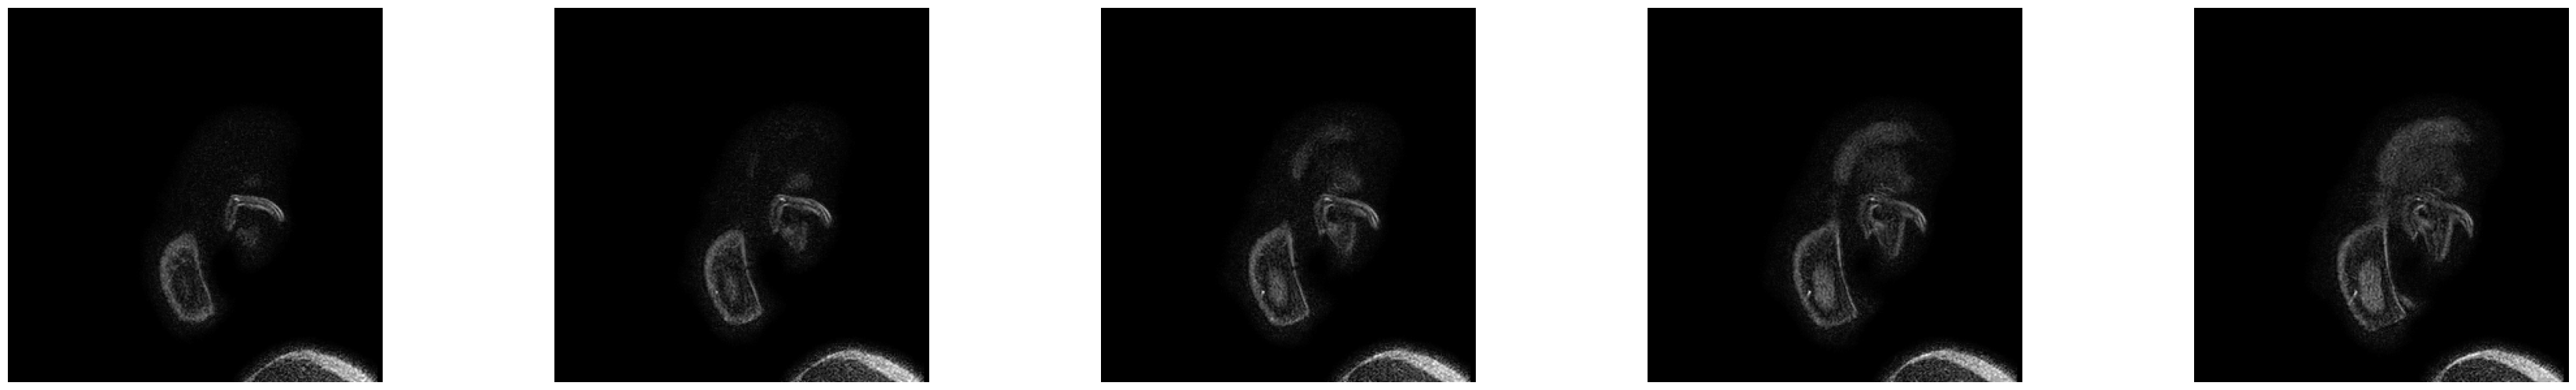

In [9]:
print("")
print("Trainned data for  :")
print("")

Images_details(dir_name_train_Non_Parkinson)
print("")
plot_images(dir_name_train_Non_Parkinson)

In [10]:
### Data augmentation
train_datagen=ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)

In [11]:
# having train and test images
training_set=train_datagen.flow_from_directory('Dataset/Train', batch_size=32, class_mode='categorical', target_size=(255,255))
testing_set=test_datagen.flow_from_directory('Dataset/Test', batch_size=32, class_mode='categorical', target_size=(255,255))

Found 1911 images belonging to 6 classes.
Found 1911 images belonging to 6 classes.


In [15]:
## Creating cnn layer

# initialized the model
model=Sequential()  

# Adding first convolution layer
model.add(Convolution2D(32,(3,3),input_shape=(255,255,3), padding='same', activation='relu'))

# Adding first Maxpool layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Adding Flatten layer
model.add(Flatten())

# Adding input layer
model.add(Dense(units=64, activation='relu', ))

# Adding dropout layer
model.add(Dropout(0.4))

# Adding output layer
model.add(Dense(units=6, activation='softmax'))


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 255, 255, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 516128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │      33,032,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,033,542 (126.01 MB)

 Trainable params: 33,033,542 (126.01 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compilin the model

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
# Fitting the model

history= model.fit(training_set, 
          steps_per_epoch= training_set.samples//32, 
          validation_data=testing_set, 
          validation_steps= testing_set.samples//32, 
          epochs=10)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.2709 - loss: 2.7745 - val_accuracy: 0.4756 - val_loss: 1.2690
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.5000 - loss: 1.4545 - val_accuracy: 0.4910 - val_loss: 1.2555
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4252 - loss: 1.3610 - val_accuracy: 0.4984 - val_loss: 1.1746
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.4375 - loss: 1.4113 - val_accuracy: 0.4979 - val_loss: 1.1710
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.4433 - loss: 1.2830 - val_accuracy: 0.4974 - val_loss: 1.1516
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.4062 - loss: 1.4812 - val_accuracy: 0.5000 - val_loss: 1.1475
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.4518 - loss: 1.2530 - val_accuracy: 0.4984 - val_loss: 1.1317
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.4062 - loss: 1.2322 - val_accuracy: 0.498

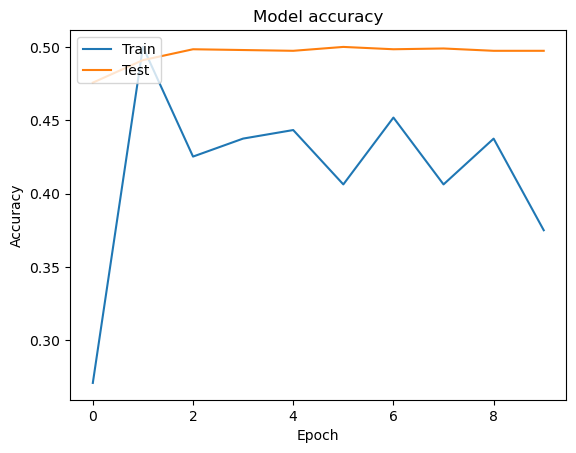

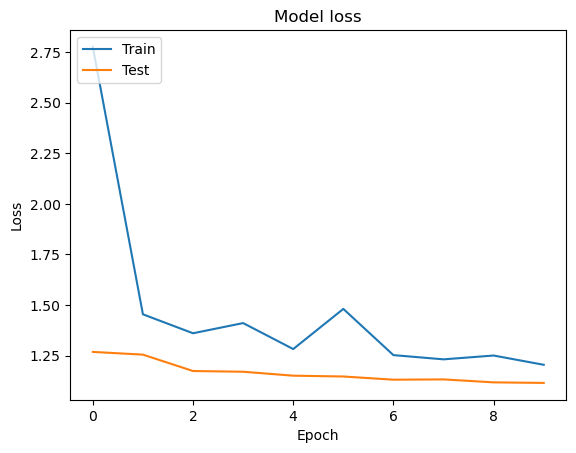

In [21]:
def plot():
    # Plot training & validation accuracy values
    
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()

    # Plot training & validation loss values
    
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()
plot()